In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from ensemble_model import EnsembleModel
import joblib

## 1. Load the Dataset

The Dataset contains one row per completed match.

Each row contains:
- the final match outcome('team0_won')
- aggreagted statistics for both teams
- statistics for each of the six players on each team
- hero an lane assignment

Statistics measured at the 5-minute snapshot.

## 2. Feature Engineering

The engineered features fall into several groups:

### Team compositions and distributions
- Carry share
- Networth standart deviation
- Richest player relative to team avarage

### Team performance
- Team kill/death ratio (KDR)

### Team-to-team differences
- Networth difference
- Damage difference
- Avarage level difference
- Carry networth difference
- KDR difference
- Gold-per-minute difference
- Objective damage difference

### Relative ratios
- Networth ratio
- Damage ratio
- Objective damage ratio

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

new_features = pd.DataFrame({
    "team0_carry_share" : (df["team0_p1_networth"]/df["team0_team_total_networth"]),
    "team1_carry_share" : (df["team1_p1_networth"]/df["team1_team_total_networth"]),
    "team0_networth_std" : df[["team0_p1_networth","team0_p2_networth","team0_p3_networth","team0_p4_networth","team0_p5_networth","team0_p6_networth"]].std(axis=1),
    "team1_networth_std" : df[["team1_p1_networth","team1_p2_networth","team1_p3_networth","team1_p4_networth","team1_p5_networth","team1_p6_networth"]].std(axis=1),
    "team0_team_kdr" : (df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1)),
    "team1_team_kdr" : (df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "team0_richest_vs_team_avg" : (df["team0_p1_networth"]/(df["team0_team_total_networth"]/6)),
    "team1_richest_vs_team_avg" : (df["team1_p1_networth"]/(df["team1_team_total_networth"]/6)),
    'networth_diff': df['team0_team_total_networth'] - df['team1_team_total_networth'],
    "damage_diff":df["team0_team_total_damage"]-df["team1_team_total_damage"],
    "level_diff":df["team0_team_avg_level"]-df["team1_team_avg_level"],
    "carry_diff":df["team0_p1_networth"] - df["team1_p1_networth"],
    "kdr_diff":(df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1))-(df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "gpm_diff" : (df["team0_team_gold_per_minute"]-df["team1_team_gold_per_minute"]),
    "objective_diff" : (df["team0_team_total_objectivedamage"]-df["team1_team_total_objectivedamage"]),
    "networth_ratio" : (df["team0_team_total_networth"]/(df["team1_team_total_networth"]+1)),
    "damage_ratio" : (df["team0_team_total_damage"]/(df["team1_team_total_damage"]+1)),
    "objective_ratio" : (df["team0_team_total_objectivedamage"]/(df["team1_team_total_objectivedamage"]+1))
})
df = pd.concat([df, new_features],axis=1)
print(df.shape)
df


(6315, 202)


,match_id,team0_won,team0_team_total_kills,team0_team_total_deaths,team0_team_total_networth,team0_team_total_damage,team0_team_total_objectivedamage,team0_team_avg_level,team0_team_gold_per_minute,team0_p1_hero,...,networth_diff,damage_diff,level_diff,carry_diff,kdr_diff,gpm_diff,objective_diff,networth_ratio,damage_ratio,objective_ratio
0,1741000,1,72,56,237513,208358,30484,25.166667,989.637475,2,...,5135,14355,0.833333,-7385,0.529825,21.395833,8657,1.022093,1.073988,1.396555
1,30579330,0,70,57,244464,227340,16059,33.333333,1003.546773,1,...,-7814,-7065,0.000000,-3045,0.426075,-32.077175,-38498,0.969022,0.969856,0.294347
2,40447085,1,69,67,289685,246054,30300,31.166667,1207.020803,64,...,28463,47241,0.166667,17769,0.085128,118.595830,19399,1.108957,1.237609,2.779307
3,40451275,1,41,45,251352,176229,13980,29.833333,1047.299974,67,...,-26204,-20315,-1.666667,-14,-0.085440,-109.183331,4049,0.905587,0.896634,1.407571
4,40328563,1,48,44,247987,172154,19335,30.333333,1033.279141,1,...,16342,-15600,2.833333,-15082,0.206667,68.091665,-12173,1.070543,0.916908,0.613634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6310,94772508,0,54,65,272899,236369,19338,34.166667,1137.079138,13,...,-51372,-29278,-1.500000,-2584,-0.345455,-214.049995,-42617,0.841574,0.889783,0.312125
6311,94773036,0,30,47,261820,228065,24506,34.000000,1090.916639,20,...,-42430,7410,-1.500000,-9705,-0.891129,-176.791662,-44200,0.860539,1.033577,0.356674
6312,94773169,0,23,40,239713,177657,13572,33.000000,998.804142,64,...,-56987,-43221,-2.166667,-16507,-0.959024,-237.445827,-37053,0.807928,0.804318,0.268084
6313,94773353,1,37,42,291046,226136,50943,34.833333,1229.598617,7,...,48494,-23388,2.000000,16353,-0.218482,204.875364,23871,1.199927,0.906266,1.881690


## 3. Train/Test Split

The data is split into 80% training and 20% test data

In [ ]:
X = df.drop(columns=["team0_won","match_id"])

y = df["team0_won"]

categorical_columns = []
for team in [0,1]:
    for i in range(1,7):
        categorical_columns.append(f'team{team}_p{i}_hero')
        categorical_columns.append(f'team{team}_p{i}_lane')

X = pd.get_dummies(X, columns=categorical_columns)
feature_columns = joblib.load("YOUR_PATH_HERE")
X = X.reindex(columns=feature_columns, fill_value=0)
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X.columns.to_list()

(6315, 679)


['team0_team_total_kills',
 'team0_team_total_deaths',
 'team0_team_total_networth',
 'team0_team_total_damage',
 'team0_team_total_objectivedamage',
 'team0_team_avg_level',
 'team0_team_gold_per_minute',
 'team0_p1_kills',
 'team0_p1_deaths',
 'team0_p1_assists',
 'team0_p1_networth',
 'team0_p1_damage',
 'team0_p1_creeps',
 'team0_p1_level',
 'team0_p1_objective_damage',
 'team0_p1_denies',
 'team0_p1_gold_per_minute',
 'team0_p1_player_healing',
 'team0_p1_self_healing',
 'team0_p2_kills',
 'team0_p2_deaths',
 'team0_p2_assists',
 'team0_p2_networth',
 'team0_p2_damage',
 'team0_p2_creeps',
 'team0_p2_level',
 'team0_p2_objective_damage',
 'team0_p2_denies',
 'team0_p2_gold_per_minute',
 'team0_p2_player_healing',
 'team0_p2_self_healing',
 'team0_p3_kills',
 'team0_p3_deaths',
 'team0_p3_assists',
 'team0_p3_networth',
 'team0_p3_damage',
 'team0_p3_creeps',
 'team0_p3_level',
 'team0_p3_objective_damage',
 'team0_p3_denies',
 'team0_p3_gold_per_minute',
 'team0_p3_player_healing'

## 4. Baseline Performance

As an initial benchmark, an XGB classifier and RandomForest classifier are trained with a relatively simple configurations.

The baseline models achive roughly 81% test accuracy

In [ ]:
model_xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=42)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy_xgb}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.8242280285035629

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.80      0.82       615
           1       0.82      0.85      0.83       648

    accuracy                           0.82      1263
   macro avg       0.82      0.82      0.82      1263
weighted avg       0.82      0.82      0.82      1263



In [5]:
importance = pd.DataFrame({"feature": X.columns, "importance": model_xgb.feature_importances_})

importance = importance.sort_values(by="importance",ascending=False)

importance

,feature,importance
173,networth_ratio,0.098073
166,networth_diff,0.049529
171,gpm_diff,0.043270
175,objective_ratio,0.030037
172,objective_diff,0.014627
...,...,...
634,team1_p5_lane_3,0.000000
633,team1_p5_lane_1,0.000000
632,team1_p5_hero_81,0.000000
631,team1_p5_hero_80,0.000000


In [ ]:
model_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy}")

print("\nRandom Forest Report:")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.8083927157561361

Random Forest Report:

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       615
           1       0.81      0.82      0.82       648

    accuracy                           0.81      1263
   macro avg       0.81      0.81      0.81      1263
weighted avg       0.81      0.81      0.81      1263



In [7]:
rf_importance = pd.DataFrame({"feature": X.columns,"importance": model_rf.feature_importances_})

rf_importance = rf_importance.sort_values(by="importance",ascending=False)

print(rf_importance.head(20))

                              feature  importance
173                    networth_ratio    0.062649
166                     networth_diff    0.057459
171                          gpm_diff    0.038128
172                    objective_diff    0.037411
175                   objective_ratio    0.032848
168                        level_diff    0.028765
85         team1_team_gold_per_minute    0.020845
4    team0_team_total_objectivedamage    0.019888
169                        carry_diff    0.019692
83   team1_team_total_objectivedamage    0.019516
6          team0_team_gold_per_minute    0.016522
2           team0_team_total_networth    0.016010
81          team1_team_total_networth    0.015921
58                  team0_p5_networth    0.012656
143          team1_p5_gold_per_minute    0.011912
163                    team1_team_kdr    0.011892
131          team1_p4_gold_per_minute    0.011329
101                 team1_p2_networth    0.011052
76           team0_p6_gold_per_minute    0.011015


## 5. Tuned XGBoost

The next experiment uses a more regularized XGBoost configuration.

In [ ]:
model_xgb = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.7,

    colsample_bytree=0.7,

    min_child_weight=7,

    gamma=2,

    reg_alpha=2,

    reg_lambda=10,

    random_state=42,
)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.8210609659540776

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       615
           1       0.82      0.84      0.83       648

    accuracy                           0.82      1263
   macro avg       0.82      0.82      0.82      1263
weighted avg       0.82      0.82      0.82      1263



The tuned model achives ~82% test accuracy and ~90% train accuracy

In [ ]:
train_acc = model_xgb.score(X_train,y_train)

test_acc = model_xgb.score(X_test,y_test)

print(train_acc)
print(test_acc)

0.9016231195566112
0.8210609659540776


### 6. ROC-AUC

Because the final application outputs a win probability rather than only a binary prediction, accuracy alone is not sufficient.

ROC-AUC measures how well the model ranks winning teams above losing teams across different probability thresholds.

For the tuned XGBoost model, the test ROC-AUC is approximately 0.908.

In [ ]:
from sklearn.metrics import roc_auc_score

probs=model_xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,probs))

0.9088000602228244


## 7. CatBoost

CatBoost is evaluated as a second gradient-boosting model.

It recieves approximately 81.2% test accuracy and 0.907 ROC-AUC score.

In [ ]:
model_cat = CatBoostClassifier(

    iterations=1500,

    depth=4,

    learning_rate=0.02,

    l2_leaf_reg=15,

    min_data_in_leaf=30,

    random_strength=5,

    bagging_temperature=2,

    verbose=100,

    random_seed=42
)

model_cat.fit(X_train, y_train)

probs = model_cat.predict_proba(X_test)[:,1]

predictions = model_cat.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for CAT: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

pred=(probs>0.5)

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs))

0:	learn: 0.6820271	total: 150ms	remaining: 3m 44s
100:	learn: 0.4241220	total: 628ms	remaining: 8.7s
200:	learn: 0.3963573	total: 1.05s	remaining: 6.81s
300:	learn: 0.3858319	total: 1.49s	remaining: 5.92s
400:	learn: 0.3786537	total: 1.96s	remaining: 5.38s
500:	learn: 0.3688889	total: 2.42s	remaining: 4.83s
600:	learn: 0.3562410	total: 2.85s	remaining: 4.26s
700:	learn: 0.3421895	total: 3.28s	remaining: 3.73s
800:	learn: 0.3270989	total: 3.72s	remaining: 3.25s
900:	learn: 0.3147469	total: 4.17s	remaining: 2.77s
1000:	learn: 0.3035893	total: 4.59s	remaining: 2.29s
1100:	learn: 0.2938296	total: 5.03s	remaining: 1.82s
1200:	learn: 0.2848106	total: 5.45s	remaining: 1.36s
1300:	learn: 0.2755648	total: 5.89s	remaining: 900ms
1400:	learn: 0.2664331	total: 6.31s	remaining: 446ms
1499:	learn: 0.2580325	total: 6.72s	remaining: 0us
Accuracy for CAT: 0.8123515439429929

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      

In [ ]:
train_acc = model_cat.score(X_train, y_train)

test_acc = model_cat.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.9010292953285828
0.8123515439429929


## 8. Ensemble Model

The final predictor combines the XGBoost and CatBoost models using simple soft-voting ensemble. For each match, both models produce class probabilities, which are then avaraged using arithmetic mean.

On the test set ensemble achieves approxiamtely 81.6% accuracy and 0.909 ROC-AUC score.

In [ ]:
ensemble = EnsembleModel(model_xgb, model_cat)
joblib.dump(ensemble, 'YOUR_PATH_HERE')

pred = ensemble.predict(X_test)
probs = ensemble.predict_proba(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs[:, 1]))

0.8163103721298496
0.9093521027802871


## 9. Calibration Curve

A calibration curve compares predicted probabilities with the observed frequency of the positive class.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_xgb, method='isotonic', cv=5)

calibrated.fit( X_train,y_train)

probs = calibrated.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, probs))

0.908618137107297


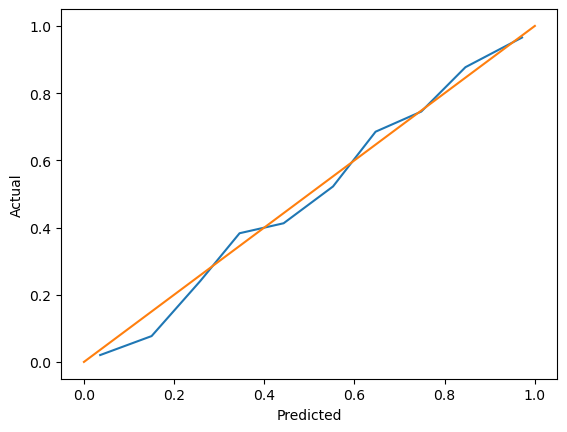

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true)

plt.plot([0,1], [0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 10. Model Explainability with SHAP

SHAP is used to investigate which features influence the XGBoost predictions.

Two visualizations are produced:

1. A SHAP summary plot showing the overall importance and direction of feature contributions.
2. A bar plot showing aggregated feature importance.

This provides an interpretable view of which aspects of the game influance the model prediction the most.

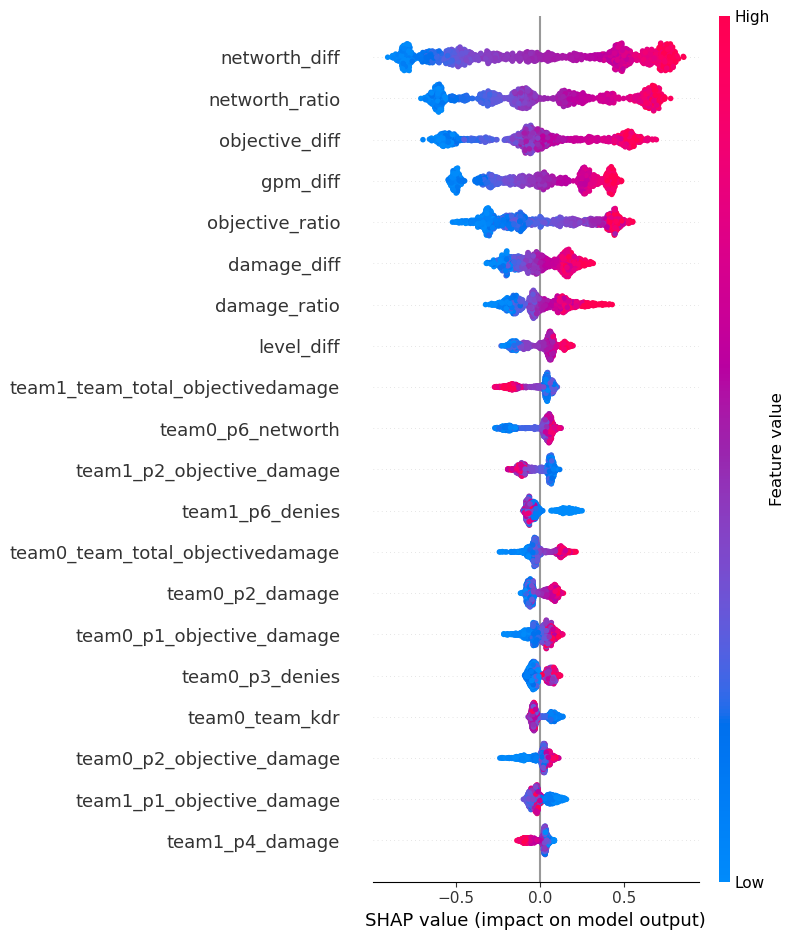

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = (explainer.shap_values( X_test))

shap.summary_plot(shap_values, X_test)

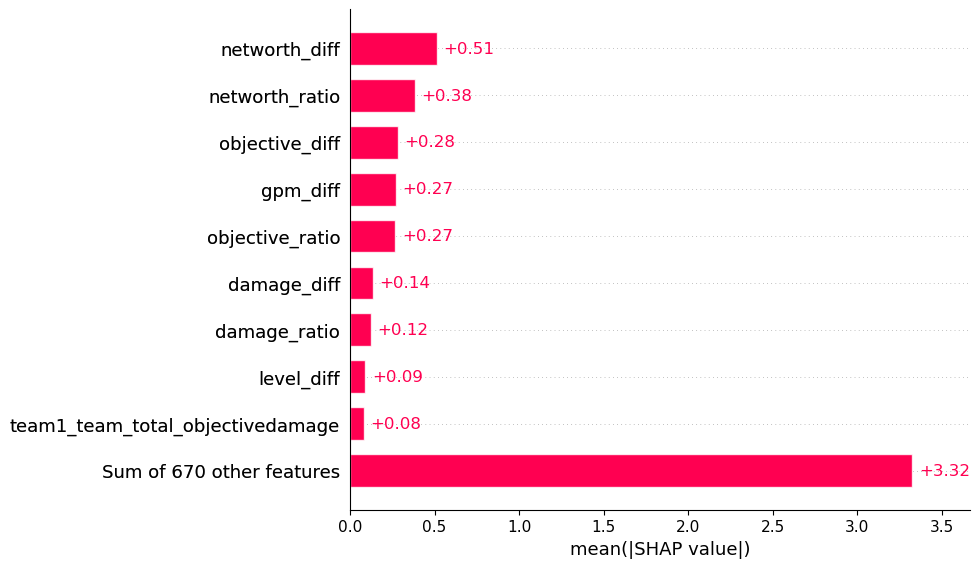

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X_test.values, feature_names=X_test.columns))